# AirBnB Rio - Data Analytics Project

AirBnB Rio Part 2 of 2

In [20]:
# Importing necessary libraries
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

## Data Cleaning

We now turn to the AirBnB dataset, which we will start by checking and cleaning the data.

In [21]:
dfmar25 = pd.read_csv("listingsMar25.csv")

In [22]:
dfmar25.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,2302715,guilherme,11706874,Guilherme,NaN,Anil,-22.95221,-43.32944,Entire home/apt,2700.0,10,0,NaN,NaN,1,365,0,NaN
1,2304688,OLIMPÍADAS 2016,10405816,Eurico,NaN,Ipanema,-22.98767,-43.18991,Entire home/apt,837.0,7,0,NaN,NaN,1,365,0,NaN
2,2306547,Amplo Apto com 3 Dormitórios em Copacabana - 1...,4107346,Vera Lucia,NaN,Copacabana,-22.97333,-43.18857,Entire home/apt,800.0,5,13,2025-03-05,0.21,1,257,3,NaN
3,2306767,Studio in Copacabana Beach,11386725,Carolina,NaN,Copacabana,-22.96477,-43.17605,Entire home/apt,190.0,3,193,2025-03-03,1.44,6,66,19,NaN
4,2308385,Copacabana Ótima opção!,11788583,Ivan,NaN,Copacabana,-22.96820,-43.18523,Entire home/apt,220.0,2,28,2025-03-01,0.21,1,242,4,NaN


In [23]:
dfmar25.dtypes

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group               float64
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                           float64
dtype: object

In [24]:
dfmar25.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
count,4.201300e+04,4.201300e+04,0.0,42013.000000,42013.000000,38356.000000,42013.000000,42013.000000,33140.000000,42013.000000,42013.000000,42013.000000,0.0
mean,7.444710e+17,2.256052e+08,NaN,-22.966277,-43.248424,720.284832,3.609526,23.684859,1.263767,9.338990,188.777878,8.113965,NaN
std,5.391705e+17,2.103432e+08,NaN,0.035432,0.100336,4165.194984,14.249756,45.877236,1.277616,24.426124,128.669915,12.482438,NaN
min,1.787800e+04,3.607000e+03,NaN,-23.073830,-43.723009,30.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000,NaN
25%,4.625830e+07,3.500060e+07,NaN,-22.984390,-43.300392,220.000000,1.000000,1.000000,0.320000,1.000000,76.000000,0.000000,NaN
50%,9.494565e+17,1.501449e+08,NaN,-22.971860,-43.193719,343.000000,2.000000,6.000000,0.930000,2.000000,173.000000,2.000000,NaN
75%,1.236132e+18,4.149635e+08,NaN,-22.952710,-43.184728,600.000000,3.000000,26.000000,1.860000,5.000000,329.000000,11.000000,NaN
max,1.379824e+18,6.848057e+08,NaN,-22.750510,-43.104400,500000.000000,1000.000000,726.000000,13.650000,214.000000,365.000000,161.000000,NaN


There are certainly questionable entries here. Hard to believe that any listing has a *daily* price of 50k brazilian reais (~$10k) or a thousand days as the minimum number of nights. 

Let's take a look at them and attempt to find a reasonable cutting off point that separates the absurd outliers from the realistic ones:

In [25]:
#fig, ax = plt.subplots(figsize=(8, 3))
#sns.boxplot(x=dfmar25['price'])
#plt.xlim(0, 1200)

In [26]:
#fig, ax = plt.subplots(figsize=(8, 3))
#sns.histplot(x=dfmar25[dfmar25['price']<=1200]['price'], bins=30, color='grey', ax=ax)
#plt.xlim(0, 1200)

In [27]:
#fig, ax = plt.subplots(figsize=(8, 3))
#sns.kdeplot(x=dfmar25['price'], color='grey', fill=True, ax=ax)
#plt.xlim(0, 6000)

Text(0.5, 1.0, 'Density Plot of Airbnb Prices in Rio (no outliers)')

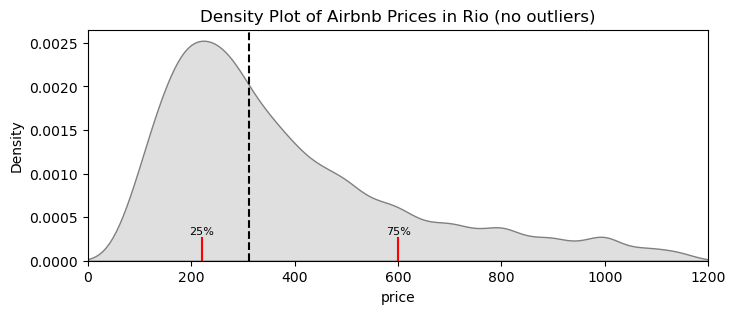

In [30]:
# This density plot zooms in on the price statistics, ignoring most outliers
Q1 = dfmar25['price'].quantile(0.25)
Q3 = dfmar25['price'].quantile(0.75)
IQR = Q3 - Q1
outliers = dfmar25[dfmar25['price'] > (Q3 + 1.5 * IQR)]
no_outliers = dfmar25[dfmar25['price'] <= (Q3 + 1.5 * IQR)]

# Plotting
fig, ax = plt.subplots(figsize=(8, 3))
#sns.kdeplot(x=dfmar25['price'], color='grey', fill=True, ax=ax)
sns.kdeplot(x=no_outliers['price'], color='grey', fill=True, ax=ax)

# Median line
median = no_outliers['price'].median()
ax.axvline(median, color='black', linestyle='--')

# Now the quantiles
ax.axvline(Q1, ymax = 0.1, color='red')
ax.axvline(Q3, ymax = 0.1, color='red')
ax.text(
        Q1, # x-coordinate
        0.0003, # y-coordinate
        f'25%', # text
        horizontalalignment='center', # centered
        fontsize=8, # small font size
    )
ax.text(
        Q3, # x-coordinate
        0.0003, # y-coordinate
        f'75%', # text
        horizontalalignment='center', # centered
        fontsize=8, # small font size
    )
plt.xlim(0, 1200)
plt.title("Density Plot of Airbnb Prices in Rio (no outliers)")

Number of outliers: 3797
Number of outliers of outliers: 402


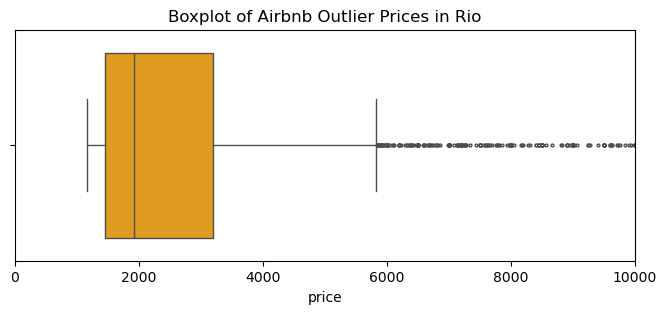

In [31]:
# On the other hand, the following boxplot looks at ONLY the outliers
fig, ax = plt.subplots(figsize=(8, 3))
sns.boxplot(x=outliers['price'], color='orange', fill=True, ax=ax, fliersize=2)
plt.xlim(0, 10000)
plt.title("Boxplot of Airbnb Outlier Prices in Rio")

# Still a lot of values outside the interquartile range (of the set of outliers no less).
print(f"Number of outliers: {len(outliers)}")
print(f"Number of outliers of outliers: {len(outliers[outliers['price'] > 6000])}")

Text(0.5, 1.0, 'Outliers vs No Outliers Price Density Plot')

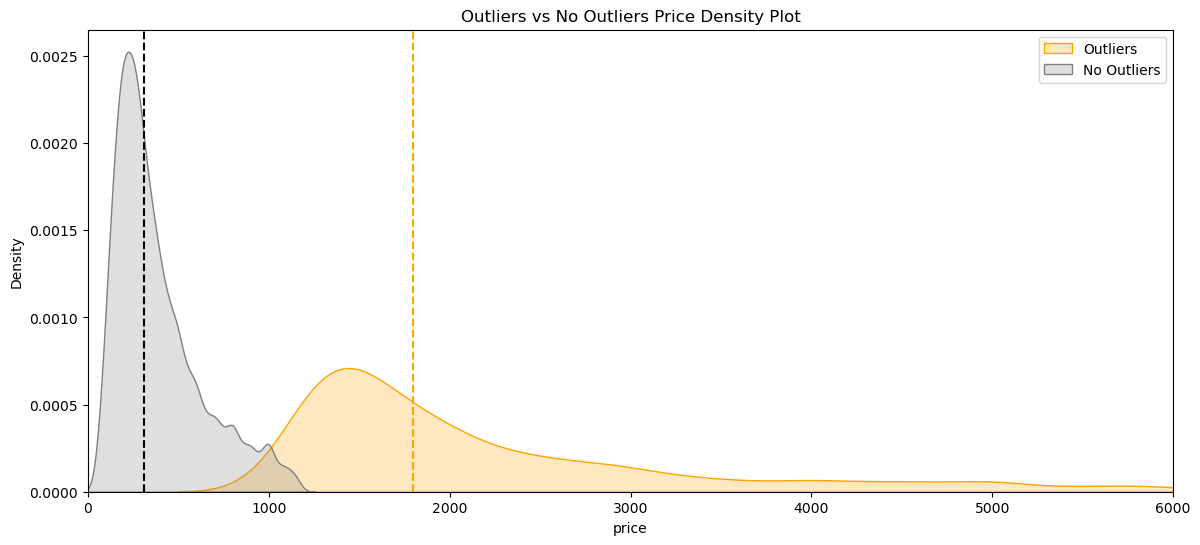

In [34]:
# Let's exclude the extreme outliers and see the density plot of the outliers that are still realistic
outliersv2 = outliers[outliers['price'] <= 6000]
fig, ax = plt.subplots(figsize=(14, 6))
sns.kdeplot(x=outliersv2['price'], color='orange', fill=True, ax=ax)
sns.kdeplot(x=no_outliers['price'], color='grey', fill=True, ax=ax)

# Median lines
median1 = no_outliers['price'].median()
ax.axvline(median1, color='black', linestyle='--')
median2 = outliersv2['price'].median()
ax.axvline(median2, color='orange', linestyle='--')

ax.legend(labels=['Outliers', 'No Outliers'])
plt.xlim(0, 6000)
plt.title("Outliers vs No Outliers Price Density Plot")

Even within the outliers there are outliers.

As such, we will delete the listings within those 402 'absurd outliers' and keep the remaining 3395 as our 'realistic outliers'

In [35]:
# Excluding the 402 listings with absurd daily prices (over 6000 reais)
dfmar25 = dfmar25[dfmar25['price'] <= 6000]

Text(0.5, 1.0, 'Density Plot of Airbnb Prices in Rio')

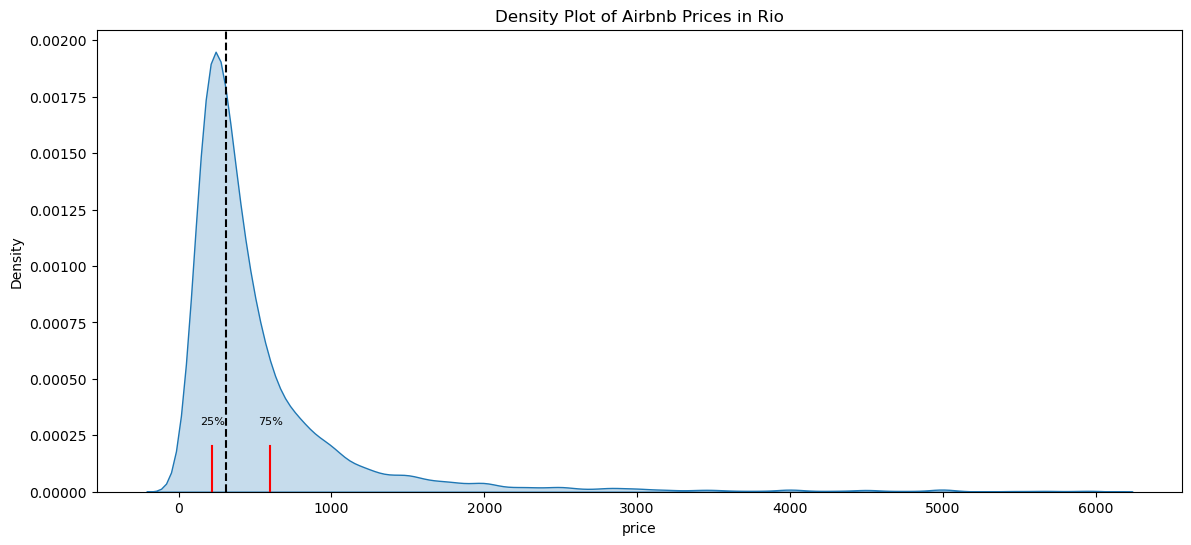

In [36]:
#The following is the *complete* density plot of the price column, with all (realistic) outliers *included*
fig, ax = plt.subplots(figsize=(14, 6))
sns.kdeplot(x=dfmar25['price'], fill=True)

# Median line
ax.axvline(median, color='black', linestyle='--')
median = no_outliers['price'].median()

# Now the quartiles
ax.axvline(Q1, ymax = 0.1, color='red')
ax.axvline(Q3, ymax = 0.1, color='red')
ax.text(
        Q1, # x-coordinate
        0.0003, # y-coordinate
        f'25%', # text
        horizontalalignment='center', # centered
        fontsize=8, # small font size
    )
ax.text(
        Q3, # x-coordinate
        0.0003, # y-coordinate
        f'75%', # text
        horizontalalignment='center', # centered
        fontsize=8, # small font size
    )
plt.title("Density Plot of Airbnb Prices in Rio")

And thus we see that the distribuition of listing prices skews to the right, even accounting for the absurd outlier values

Let's do the same with 'minimum nights'

Text(0.5, 1.0, 'Histogram Plot of Airbnb Minimum Nights in Rio (no outliers)')

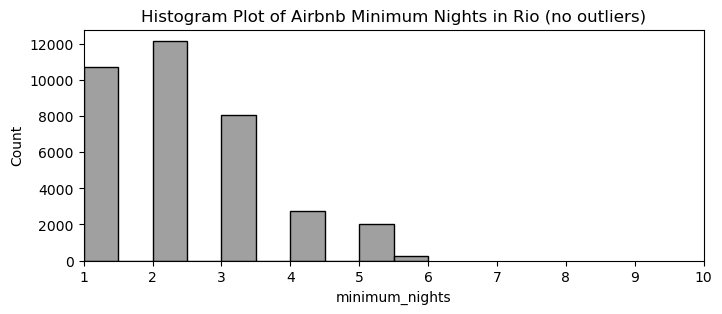

In [39]:
# This histogram zooms in on the price statistics, ignoring most outliers
Q1 = dfmar25['minimum_nights'].quantile(0.25)
Q3 = dfmar25['minimum_nights'].quantile(0.75)
IQR = Q3 - Q1
outliers = dfmar25[dfmar25['minimum_nights'] > (Q3 + 1.5 * IQR)]
no_outliers = dfmar25[dfmar25['minimum_nights'] <= (Q3 + 1.5 * IQR)]

# Plotting
fig, ax = plt.subplots(figsize=(8, 3))
sns.histplot(data=no_outliers, x='minimum_nights', bins=10, color='grey', fill=True, ax=ax)

# Median line
#ax.axvline(median, color='black', linestyle='--')
#median = no_outliers['minimum_nights'].median()

plt.xlim(1, 10)
plt.title("Histogram Plot of Airbnb Minimum Nights in Rio (no outliers)")

Number of outliers: 1957
Number of outliers of outliers: 60


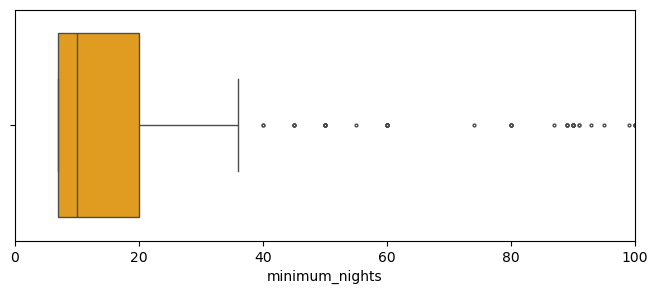

In [40]:
# Again, this boxplot looks at ONLY the outliers
fig, ax = plt.subplots(figsize=(8, 3))
sns.boxplot(x=outliers['minimum_nights'], color='orange', fill=True, ax=ax, fliersize=2)
plt.xlim(0, 100)

# Still a considerable amount of values outside the interquartile range (of the set of outliers no less).
print(f"Number of outliers: {len(outliers)}")
print(f"Number of outliers of outliers: {len(outliers[outliers['minimum_nights'] > 100])}")

In [41]:
# Excluding the 60 listings with absurd minimum night requirements (over 40 nights)
dfmar25 = dfmar25[dfmar25['minimum_nights'] <= 40]

Text(0.5, 1.0, 'Histogram of Airbnb Minimum Nights in Rio')

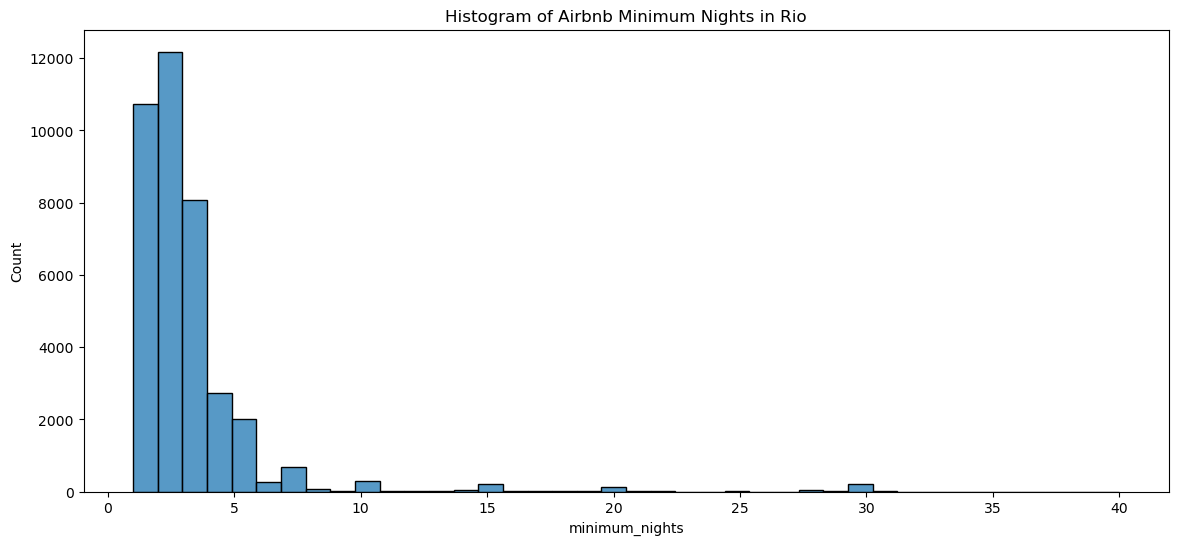

In [42]:
#This the complete histogram of the minimum_nights column, with all (realistic) outliers included
fig, ax = plt.subplots(figsize=(14, 6))
sns.histplot(data=dfmar25, x='minimum_nights', bins = 40, fill=True)

plt.title("Histogram of Airbnb Minimum Nights in Rio")

### Missing Values

In [43]:
# Checking for missing values in the dataset
dfmar25.isna().sum()

id                                    0
name                                  0
host_id                               0
host_name                             4
neighbourhood_group               37790
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                        7632
reviews_per_month                  7632
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                           37790
dtype: int64

* Neighbourhood_group seems entirely empty, and in addition, it should be a string type column.
* last_review could be date type.
* license is entirely missing and could be dropped as column.

#### Populating the Neighbourd Group Column

Now, regarding the neighbourhood group column, let's populate it using our premade Neighbourhood.csv

In [44]:
dfNH = pd.read_csv("Neighbourhood_CISP.csv")

In [45]:
dfNH.head(10)

,Neighbourhood,RISP,AISP,CISP,neighbourhood_group
0,Catete,1,2,9,Zona Sul
1,Cosme Velho,1,2,9,Zona Sul
2,Flamengo,1,2,9,Zona Sul
3,Glória,1,2,9,Zona Central
4,Laranjeiras,1,2,9,Zona Sul
5,Botafogo,1,2,10,Zona Sul
6,Humaitá,1,2,10,Zona Sul
7,Urca,1,2,10,Zona Sul
8,Cachambi,1,3,23,Zona Norte
9,Méier,1,3,23,Zona Norte


In [46]:
dfmar25 = dfmar25.merge(dfNH[['Neighbourhood', 'neighbourhood_group']], left_on='neighbourhood', right_on='Neighbourhood', how='left')

In [47]:
dfmar25.head(10)

,id,name,host_id,host_name,neighbourhood_group_x,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,Neighbourhood,neighbourhood_group_y
0,2302715,guilherme,11706874,Guilherme,NaN,Anil,-22.952210,-43.329440,Entire home/apt,2700.0,10,0,NaN,NaN,1,365,0,NaN,Anil,Zona Sudoeste
1,2304688,OLIMPÍADAS 2016,10405816,Eurico,NaN,Ipanema,-22.987670,-43.189910,Entire home/apt,837.0,7,0,NaN,NaN,1,365,0,NaN,Ipanema,Zona Sul
2,2306547,Amplo Apto com 3 Dormitórios em Copacabana - 1...,4107346,Vera Lucia,NaN,Copacabana,-22.973330,-43.188570,Entire home/apt,800.0,5,13,2025-03-05,0.21,1,257,3,NaN,Copacabana,Zona Sul
3,2306767,Studio in Copacabana Beach,11386725,Carolina,NaN,Copacabana,-22.964770,-43.176050,Entire home/apt,190.0,3,193,2025-03-03,1.44,6,66,19,NaN,Copacabana,Zona Sul
4,2308385,Copacabana Ótima opção!,11788583,Ivan,NaN,Copacabana,-22.968200,-43.185230,Entire home/apt,220.0,2,28,2025-03-01,0.21,1,242,4,NaN,Copacabana,Zona Sul
5,2309065,Casa da Santa - Recanto do sagüi,4168313,Matthieu,NaN,Santa Teresa,-22.916679,-43.192287,Private room,401.0,2,36,2025-01-18,0.48,4,8,8,NaN,Santa Teresa,Zona Central
6,2309085,"CHARMOSO STUDIO COLADO NA PRAIA. POSTO 6. AR, ...",6217672,Fernando,NaN,Copacabana,-22.983190,-43.189900,Entire home/apt,219.0,7,58,2025-02-25,0.52,12,205,10,NaN,Copacabana,Zona Sul
7,2309998,"Quiet, bright and comfortable",11796463,Regina,NaN,Laranjeiras,-22.942740,-43.190160,Entire home/apt,399.0,3,38,2025-02-21,0.40,1,107,11,NaN,Laranjeiras,Zona Sul
8,2312206,Great Location between Copacabana/Ipanema/Arpo...,1618486,Denise,NaN,Ipanema,-22.983530,-43.195670,Entire home/apt,255.0,3,28,2025-03-05,0.21,1,316,3,NaN,Ipanema,Zona Sul
9,2312561,Rio de Janeiro Luxury - Beautiful Cozy Apartment,11809985,Louis,NaN,Copacabana,-22.964197,-43.181351,Entire home/apt,1127.0,7,3,2023-02-27,0.02,1,365,0,NaN,Copacabana,Zona Sul


In [48]:
# Are there any mismatches between the neighbourhood names in the two datasets?
dfmar25[dfmar25['neighbourhood']!=dfmar25['Neighbourhood']]
print(dfmar25[dfmar25['neighbourhood']!=dfmar25['Neighbourhood']].size)

# Which neighbourhoods are missing?
print(dfmar25[dfmar25['neighbourhood']!=dfmar25['Neighbourhood']]['neighbourhood'].unique())
#dfmar25[dfmar25['neighbourhood']!=dfmar25['Neighbourhood']].head(10)

480
['Osvaldo Cruz' 'Turiaçú' 'Freguesia (Ilha)' 'Complexo do Alemão']


In [49]:
# Let's fix that
missingN = ['Osvaldo Cruz', 'Turiaçú', 'Freguesia (Ilha)', 'Complexo do Alemão']
mask = dfmar25['neighbourhood'].isin(missingN)
dfmar25.loc[mask, 'Neighbourhood'] = dfmar25.loc[mask, 'neighbourhood']

# All of them happen to belong to 'Zona Norte' group
dfmar25.loc[mask, 'neighbourhood_group_y'] = 'Zona Norte'

# Test -Any mismatches still?
print(dfmar25[dfmar25['neighbourhood']!=dfmar25['Neighbourhood']].size)
#print(dfmar25[dfmar25['neighbourhood']!=dfmar25['Neighbourhood']]['neighbourhood'].unique())

0


In [50]:
# Let's turn neighbour_group_x into the new neighbourhood group column 
# (One time only change)
dfmar25 = dfmar25[['id', 'name', 'host_id', 'host_name', 'neighbourhood_group_y','neighbourhood_group_x', 'neighbourhood', 'Neighbourhood','latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']]
dfmar25.rename(columns={"neighbourhood_group_y": "neighbourhood_group"}, inplace=True)

dfmar25.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood_group_x,neighbourhood,Neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2302715,guilherme,11706874,Guilherme,Zona Sudoeste,NaN,Anil,Anil,-22.95221,-43.32944,Entire home/apt,2700.0,10,0,NaN,NaN,1,365
1,2304688,OLIMPÍADAS 2016,10405816,Eurico,Zona Sul,NaN,Ipanema,Ipanema,-22.98767,-43.18991,Entire home/apt,837.0,7,0,NaN,NaN,1,365
2,2306547,Amplo Apto com 3 Dormitórios em Copacabana - 1...,4107346,Vera Lucia,Zona Sul,NaN,Copacabana,Copacabana,-22.97333,-43.18857,Entire home/apt,800.0,5,13,2025-03-05,0.21,1,257
3,2306767,Studio in Copacabana Beach,11386725,Carolina,Zona Sul,NaN,Copacabana,Copacabana,-22.96477,-43.17605,Entire home/apt,190.0,3,193,2025-03-03,1.44,6,66
4,2308385,Copacabana Ótima opção!,11788583,Ivan,Zona Sul,NaN,Copacabana,Copacabana,-22.96820,-43.18523,Entire home/apt,220.0,2,28,2025-03-01,0.21,1,242


In [51]:
# And then delete the old columns
dfmar25 = dfmar25.drop(columns=['neighbourhood_group_x'])
dfmar25 = dfmar25.drop(columns=['Neighbourhood'])

In [239]:
dfmar25.head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2302715,guilherme,11706874,Guilherme,Zona Sudoeste,Anil,-22.952210,-43.329440,Entire home/apt,2700.0,10,0,NaN,NaN,1,365
1,2304688,OLIMPÍADAS 2016,10405816,Eurico,Zona Sul,Ipanema,-22.987670,-43.189910,Entire home/apt,837.0,7,0,NaN,NaN,1,365
2,2306547,Amplo Apto com 3 Dormitórios em Copacabana - 1...,4107346,Vera Lucia,Zona Sul,Copacabana,-22.973330,-43.188570,Entire home/apt,800.0,5,13,2025-03-05,0.21,1,257
3,2306767,Studio in Copacabana Beach,11386725,Carolina,Zona Sul,Copacabana,-22.964770,-43.176050,Entire home/apt,190.0,3,193,2025-03-03,1.44,6,66
4,2308385,Copacabana Ótima opção!,11788583,Ivan,Zona Sul,Copacabana,-22.968200,-43.185230,Entire home/apt,220.0,2,28,2025-03-01,0.21,1,242
5,2309065,Casa da Santa - Recanto do sagüi,4168313,Matthieu,Zona Central,Santa Teresa,-22.916679,-43.192287,Private room,401.0,2,36,2025-01-18,0.48,4,8
6,2309085,"CHARMOSO STUDIO COLADO NA PRAIA. POSTO 6. AR, ...",6217672,Fernando,Zona Sul,Copacabana,-22.983190,-43.189900,Entire home/apt,219.0,7,58,2025-02-25,0.52,12,205
7,2309998,"Quiet, bright and comfortable",11796463,Regina,Zona Sul,Laranjeiras,-22.942740,-43.190160,Entire home/apt,399.0,3,38,2025-02-21,0.40,1,107
8,2312206,Great Location between Copacabana/Ipanema/Arpo...,1618486,Denise,Zona Sul,Ipanema,-22.983530,-43.195670,Entire home/apt,255.0,3,28,2025-03-05,0.21,1,316
9,2312561,Rio de Janeiro Luxury - Beautiful Cozy Apartment,11809985,Louis,Zona Sul,Copacabana,-22.964197,-43.181351,Entire home/apt,1127.0,7,3,2023-02-27,0.02,1,365


## Unimodal Distribuitions

We've looked at the price and minimum_nights distributions already when rooting out unrealistic outliers, but there are still a few variables left.

#### Room Types

room_type
Entire home/apt    30266
Hotel room            15
Private room        7122
Shared room          387
dtype: int64


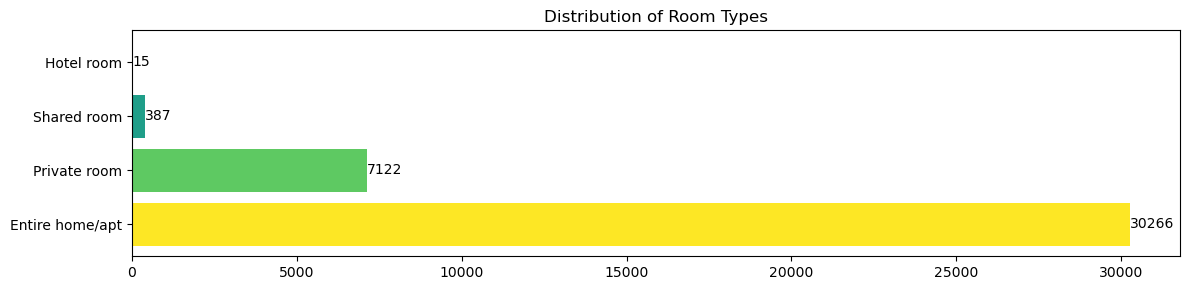

In [219]:
# We can't group by neighbourhood group yet, and neighbourhood has too many distinct values, but we *can* check the distribution of room types
print(dfmar25.groupby("room_type").size())
#dfmar25.groupby("room_type").size().plot(kind="bar") # WIP
fig, ax = plt.subplots(figsize = (12,3))
#ax.bar(x = dfmar25['room_type'].value_counts().index, height = dfmar25['room_type'].value_counts().values)
colorViridis = ['#fde725',
                '#5ec962',
                '#1f9e89',
                '#3b528b']
ax.barh(y = dfmar25['room_type'].value_counts().index, width = dfmar25['room_type'].value_counts().values, color=colorViridis)
ax.bar_label(ax.containers[0])
plt.title("Distribution of Room Types")
plt.tight_layout()

Room type categorical variables are very unbalanced. Just something to keep in mind.

#### Neighbourhoods and Neighbourhood Groups

C:\Users\BRUNO\AppData\Local\Temp\ipykernel_2112\130498802.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=dfmar25, y='neighbourhood_group', order=dfmar25['neighbourhood_group'].value_counts().index, palette=colors, ax=ax)


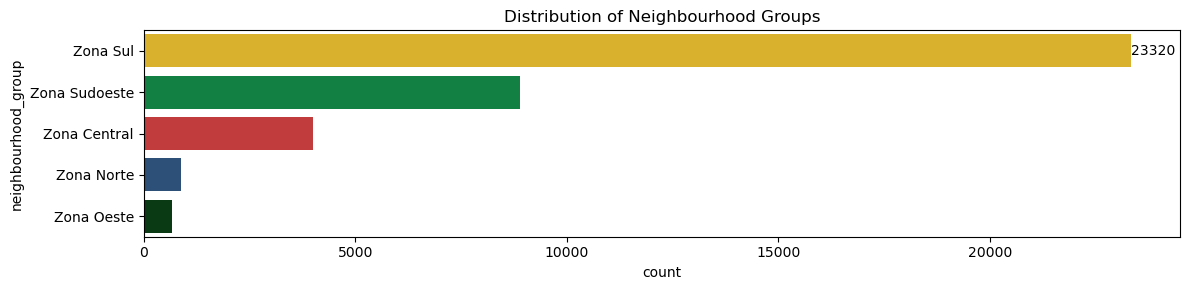

In [74]:
#fig, ax = plt.subplots(figsize = (12,3))
colors = ['#f6c10f', '#00923f', '#d72727', '#1f5085', '#02420e']

#ax.barh(y = dfmar25['neighbourhood_group'].value_counts().index, width = dfmar25['neighbourhood_group'].value_counts().values, color=colors)
#ax.bar_label(ax.containers[0])
#plt.title("Distribution of Neighbourhood Groups")
#plt.tight_layout()

# Now the same but as a seaborn countplot
fig, ax = plt.subplots(figsize=(12, 3)) 
sns.countplot(data=dfmar25, y='neighbourhood_group', order=dfmar25['neighbourhood_group'].value_counts().index, palette=colors, ax=ax)
ax.bar_label(ax.containers[0])
plt.title("Distribution of Neighbourhood Groups")
plt.tight_layout()

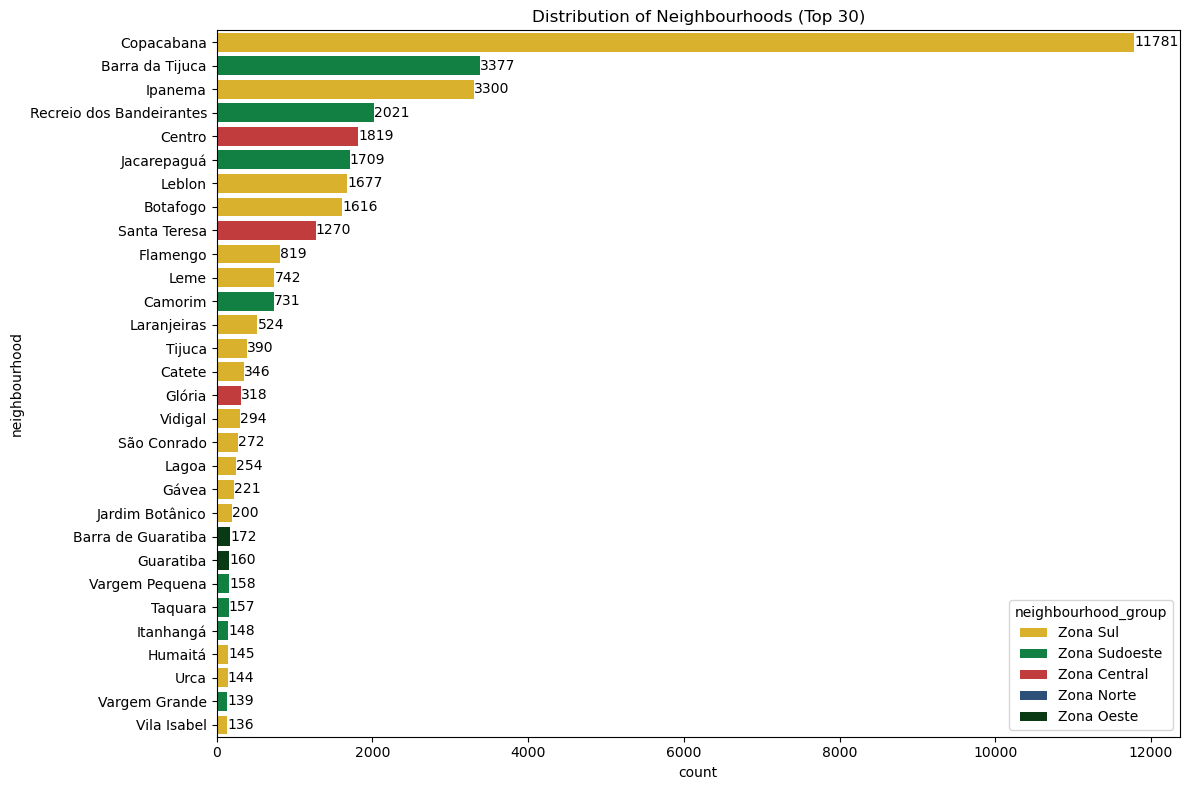

In [68]:
top30 = dfmar25['neighbourhood'].value_counts().nlargest(30)
dftop30 = dfmar25[dfmar25['neighbourhood'].isin(top30.index)]
#dftop30.head()

fig, ax = plt.subplots(figsize=(12, 8))
hue_order = ['Zona Sul', 'Zona Sudoeste', 'Zona Central', 'Zona Norte', 'Zona Oeste']
sns.countplot(
	data=dftop30,
	y='neighbourhood',
	order=top30.index,
	hue='neighbourhood_group',
	hue_order=hue_order,
	palette=colors,
	ax=ax,
)

# label all of the bar containers (one per hue level)
for container in ax.containers:
	ax.bar_label(container)

plt.title("Distribution of Neighbourhoods (Top 30)")
plt.tight_layout()

#### Numeric Columns

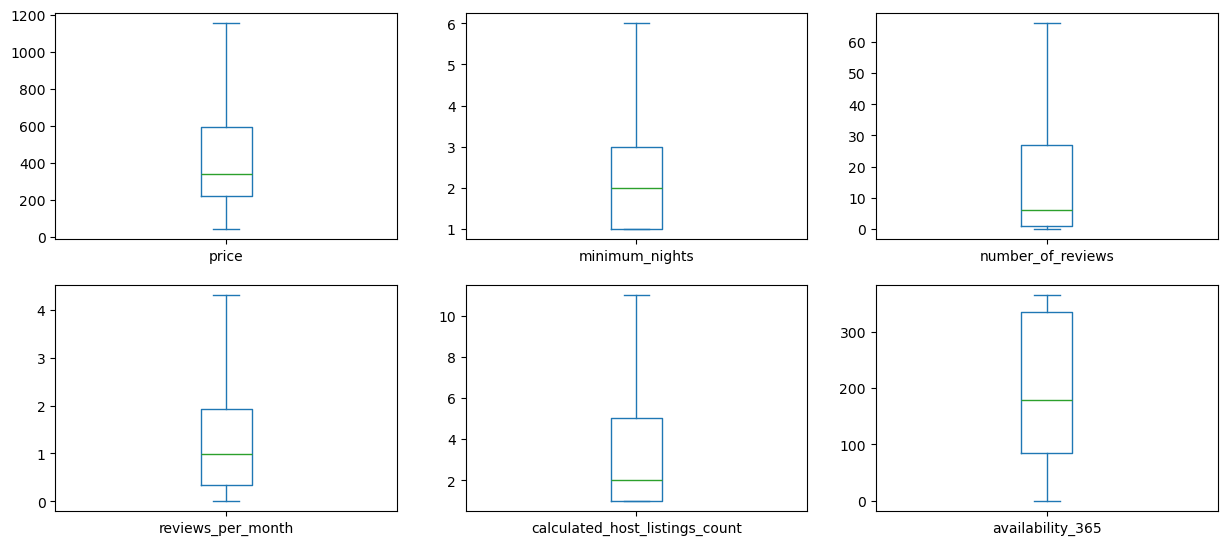

In [76]:
# Let's take a closer look at the numeric columns
# Excluding outliers for better visualization, but we can check them later
cols = [
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
    #"number_of_reviews_ltm",
]
# dfmar25[cols].hist(figsize = (15, 10))
dfmar25[cols].plot(kind = 'box', subplots = True, layout = (3,3), sharex = False, sharey = False, showfliers=False, figsize = (15,10))
plt.show()

### Bivariate Distributions

#### Neighbourhood and Neighbourhood Group

[Text(0, 0, '172'), Text(0, 0, '160')]

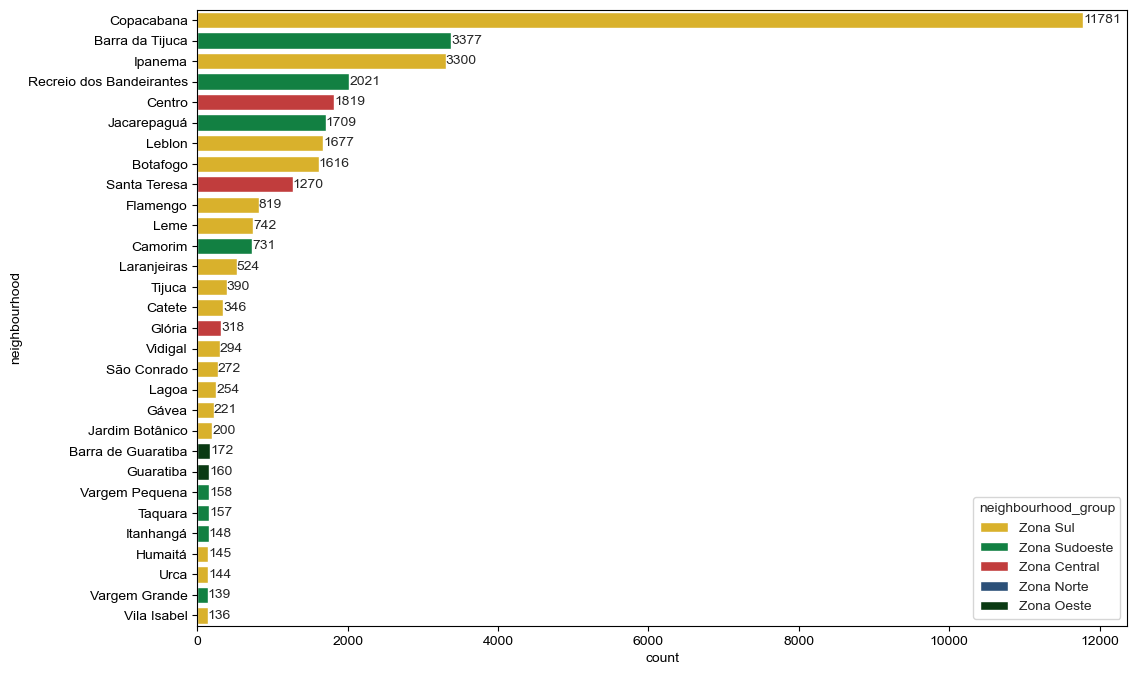

In [ ]:
# Seaborn treemap plot featuring the neighbourhood groups and the neighbourhoods that make them up


#### Price and Neighbourhood

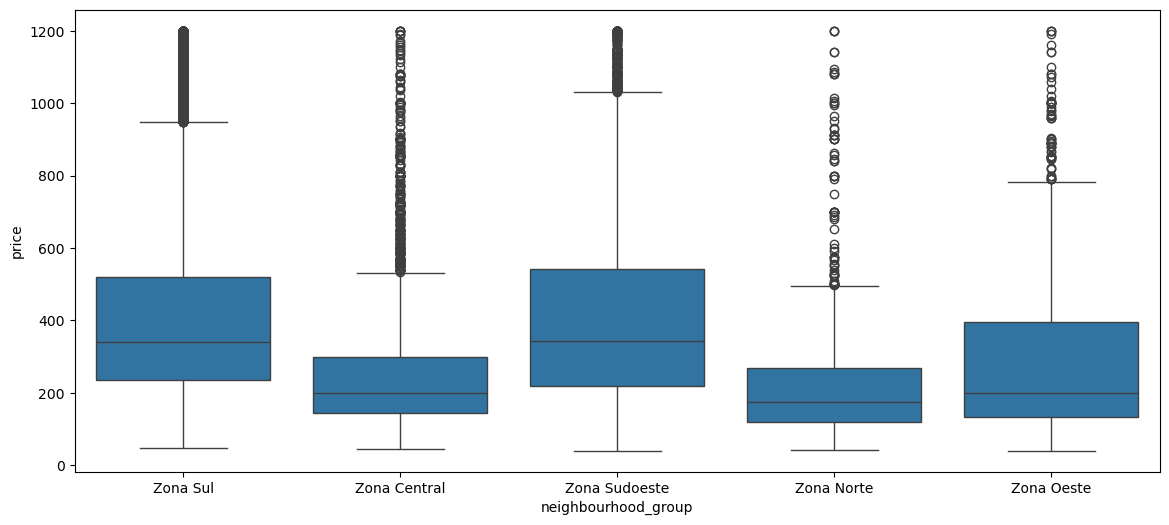

In [83]:
# Seaborn boxplots for the price of each neighbourhood group 
# Limited to 1200 for better visualization
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(x="neighbourhood_group", y="price", data=dfmar25[dfmar25['price'] <= 1200], ax=ax)
plt.show()


## Correlations

In [14]:
numeric_cols = dfmar25.select_dtypes(include=[np.number])
numeric_cols.corr(method='pearson')

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
id,1.000000,0.433933,NaN,0.039082,-0.007540,-0.023649,-0.061842,-0.385192,0.294716,0.023555,0.007565,-0.082349,NaN
host_id,0.433933,1.000000,NaN,0.027961,-0.115963,-0.024235,-0.038381,-0.183485,0.146905,-0.139830,0.048160,-0.047593,NaN
neighbourhood_group,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,0.039082,0.027961,NaN,1.000000,0.382588,-0.041711,-0.001279,-0.036155,0.023149,-0.064705,0.024790,-0.012418,NaN
longitude,-0.007540,-0.115963,NaN,0.382588,1.000000,-0.009864,-0.005605,0.104488,0.073310,0.051780,-0.147564,0.107844,NaN
price,-0.023649,-0.024235,NaN,-0.041711,-0.009864,1.000000,0.022355,-0.038164,-0.042687,0.017743,0.047880,-0.051703,NaN
minimum_nights,-0.061842,-0.038381,NaN,-0.001279,-0.005605,0.022355,1.000000,-0.029481,-0.074564,-0.010966,0.018055,-0.056470,NaN
number_of_reviews,-0.385192,-0.183485,NaN,-0.036155,0.104488,-0.038164,-0.029481,1.000000,0.406385,-0.013600,-0.122528,0.677104,NaN
reviews_per_month,0.294716,0.146905,NaN,0.023149,0.073310,-0.042687,-0.074564,0.406385,1.000000,0.021182,-0.096453,0.745773,NaN
calculated_host_listings_count,0.023555,-0.139830,NaN,-0.064705,0.051780,0.017743,-0.010966,-0.013600,0.021182,1.000000,0.038227,0.025336,NaN


WIP FALTA SELECIONAR AS VARIÀVEIS QUE FAZEM SENTIDO CORRELACIONAR!